<a href="https://colab.research.google.com/github/mbenedicto99/SaturnProject/blob/main/fase2_saturno_v8_exec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 2 — Treinamento comparativo de modelos e melhoria de resolução para 1024px
## Versão 5 — Projeto IA Saturno

Esta versão parte diretamente da execução anterior (v4/v6-exec), com o treinamento já
estabilizado (learning rate menor, scheduler, recorte de gradiente, parada antecipada,
checkpoints de retomada, precisão mista) e a validação de conteúdo já delegada à Fase 1.
Ela traz **uma única mudança, focada e isolada**: a Fase 2 deixa de aplicar seu próprio
critério sobre quais categorias de status contam como "aprovado para treino".

**Motivação da mudança.** A execução anterior usava, quando o manifesto final da Fase 1
existia, a lista `FINAL_MANIFEST_APPROVED_STATUSES = ["confirmed", "confirmed_by_manual_review"]`.
Essa lista era definida aqui na Fase 2, não na Fase 1 — e ela excluía, por conta própria,
qualquer imagem cujo `final_status` fosse diferente desses dois valores, inclusive a fila
inteira de imagens `borderline` ainda não revisadas manualmente. O resultado prático foi um
segundo filtro de conteúdo dentro da Fase 2, redundante com o da Fase 1 e mais restritivo
do que o necessário: das 1000 imagens do catálogo, apenas 122 chegavam ao treino, não porque
a Fase 1 as tivesse rejeitado, mas porque a Fase 2 não sabia reconhecer "pendente de revisão"
como algo diferente de "reprovado".

**A correção.** A Fase 2 não define mais nenhuma lista própria de status aprovados. Ela
confia inteiramente na decisão da Fase 1: qualquer imagem cujo status (`status` ou
`final_status`, dependendo do manifesto disponível) **não** seja explicitamente `rejected`
é tratada como aprovada para treino. A única lista de status configurada aqui é
`PHASE1_REJECTED_STATUSES`, e ela existe apenas para nomear o que deve ser excluído — o
oposto do que existia antes. Se a Fase 1 decidir, no futuro, introduzir uma nova categoria
de status (por exemplo, algo diferente de `confirmed`/`borderline`/`rejected`/
`confirmed_by_manual_review`), a Fase 2 não precisa de nenhum ajuste: ela vai continuar
aceitando tudo que não estiver marcado como `rejected`. O controle sobre o que entra ou não
no dataset fica inteiramente do lado da Fase 1, que é quem tem o contexto de conteúdo e a
fila de revisão manual.

Nenhuma outra célula do notebook foi alterada em relação à execução anterior — arquiteturas,
função de perda, laço de treinamento, avaliação, quebra por severidade, explicabilidade e
super-resolução seguem exatamente como estavam.

---
**Ajustes posteriores a esta execução:** (1) leitura da coluna `quality_tier` do manifesto
final da Fase 1, com relatório separado de PSNR/SSIM/LPIPS por camada (`high`/`low`) além da
métrica agregada, salvo em `model_comparison_by_quality_tier.csv`; (2) `MAX_IMAGES_TO_UPSCALE`
alterado de 40 para `None` (sem limite), por decisão de projeto, para que a etapa de
super-resolução processe todas as imagens aprovadas pendentes em vez de uma amostra por
execução. Ver células 4, 8, 10, 18 e 36.

## 1. Instalação de dependências

O Colab já traz `torch`, `torchvision`, `pandas`, `pillow`, `tqdm` e `matplotlib`
pré-instalados e ligados à GPU disponível no ambiente; por isso esta célula não reinstala
essas bibliotecas, para não substituir a versão de `torch` já compilada para a GPU por uma
versão genérica de CPU. O que falta é instalado explicitamente: `transformers` (para
carregar o Swin2SR e o CLIP do Hugging Face), `pytorch-msssim` (SSIM diferenciável, usado
na função de perda do treinamento), `scikit-image` (métricas de avaliação
MSE/PSNR/SSIM sobre o conjunto de teste) e `lpips` (métrica perceptual complementar).

Antes de rodar o restante do notebook, confirme em *Ambiente de execução > Alterar tipo de
ambiente de execução* que uma GPU está selecionada — o treinamento das quatro arquiteturas
e, principalmente, a super-resolução em lote ficam ordens de grandeza mais lentos em CPU.

In [1]:
!pip -q install transformers pytorch-msssim scikit-image lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.3 MB/s eta 0:00:00


## 2. Imports e configuração da Fase 2

Os parâmetros abaixo controlam o treinamento das quatro arquiteturas e a etapa de
super-resolução. `RANDOM_SEED` é o mesmo usado na Fase 1. `TARGET_UPSCALE_SIZE = 1024` e
`SR_MODEL_NAME` definem a meta de resolução e o modelo do Hugging Face usado para chegar
lá — o fator 4 do Swin2SR casa exatamente com `IMAGE_SIZE = 256` (256 × 4 = 1024).

A seção de aprovação de conteúdo (3.1) não define mais critérios próprios de validação.
A única configuração relevante aqui é `PHASE1_REJECTED_STATUSES`: a lista de status que a
Fase 2 trata como excluído. Qualquer outro valor de status presente no manifesto da Fase 1
— incluindo categorias que ainda não existem hoje — é tratado como aprovado, sem exigir
nenhuma mudança nesta lista.

In [2]:
import os
import json
import math
import random
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {DEVICE}")
if DEVICE.type == "cpu":
    print("Nenhuma GPU detectada. O notebook roda em CPU, mas o treinamento e a "
          "super-resolução ficam bem mais lentos.")

# Nome do dataset criado na Fase 1 (precisa bater com DATASET_NAME de lá).
DATASET_NAME = "dataset_saturno_v1"

# Tamanho em que os pares sintéticos da Fase 1 foram gerados.
IMAGE_SIZE = 256

# Meta de resolução final e modelo de super-resolução do Hugging Face.
# O fator x4 do Swin2SR casa exatamente com IMAGE_SIZE (256 x 4 = 1024).
TARGET_UPSCALE_SIZE = 1024
SR_MODEL_NAME = "caidas/swin2SR-classical-sr-x4-64"

# ---------------------------------------------------------------------------
# Aprovação de conteúdo (reformulada nesta versão)
# ---------------------------------------------------------------------------
# A Fase 2 sempre reaproveita a decisão de conteúdo já tomada pela Fase 1
# (approved_for_training_final.csv, com fallback para approved_for_training.csv,
# e classificação própria apenas se nenhum dos dois existir -- ver seção 3.1).
#
# Antes, esta configuração incluía uma lista própria de status "aprovados"
# (FINAL_MANIFEST_APPROVED_STATUSES = ["confirmed", "confirmed_by_manual_review"]),
# que excluía por conta própria qualquer imagem "borderline" ainda não revisada
# manualmente -- um segundo filtro de conteúdo, redundante e mais restritivo do
# que o da Fase 1, que reduziu o dataset de treino para uma fração pequena do
# catálogo sem que isso refletisse uma decisão de conteúdo real da Fase 1.
#
# A partir desta versão, a regra é a oposta: a Fase 2 não decide o que é
# aprovado, só o que é excluído. PHASE1_REJECTED_STATUSES é a única lista de
# status configurada aqui, e ela existe para nomear exclusão, não aprovação.
# Qualquer status que não esteja nela -- confirmed, confirmed_by_manual_review,
# borderline, ou qualquer categoria nova que a Fase 1 venha a introduzir -- é
# tratado como aprovado para treino automaticamente, sem exigir nenhum ajuste
# aqui. Isso mantém o controle sobre o conteúdo do dataset inteiramente do
# lado da Fase 1, que é quem tem o contexto de classificação e a fila de
# revisão manual.
USE_PHASE1_APPROVAL_MANIFEST = True
PHASE1_REJECTED_STATUSES = ["rejected"]

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

# A classificação própria abaixo (STRICT_SATURN_LABEL etc.) só é usada se
# nenhum dos dois manifestos da Fase 1 for encontrado -- por exemplo, ao rodar
# esta Fase 2 contra uma Fase 1 mais antiga que ainda não gera esses arquivos.
# Os rótulos e limiares espelham os da Fase 1 recalibrada.
STRICT_SATURN_LABEL = "a clear photo of the planet Saturn showing both its disk and its rings"
STRICT_EDGE_ON_RINGS_LABEL = ("a photo of the planet Saturn with its rings seen nearly "
                               "edge-on, appearing as a thin line across the disk")
STRICT_NEGATIVE_LABELS = [
    "a photo of Saturn where the rings are not visible or too faint to see",
    "a close-up crop showing only part of a planet's disk with no rings visible",
    "a logo, icon, or website interface graphic",
    "a chart, graph, table, or diagram",
    "a photograph of a different planet or celestial object without rings",
    "a photograph unrelated to Saturn or astronomy",
]
STRICT_CONFIDENCE_THRESHOLD = 0.45
STRICT_MARGIN_THRESHOLD = 0.08
STRICT_BORDERLINE_CONFIDENCE_THRESHOLD = 0.35
# Mesma filosofia acima: também na classificação própria de fallback, a
# exclusão é definida por status "rejected", não por uma lista de status
# aprovados. confirmed e borderline contam igualmente como aprovados aqui.

# Aumento de dados nos pares sintéticos, para amenizar o efeito de um dataset
# efetivo pequeno após o filtro de conteúdo: espelhamento horizontal e
# pequenas rotações aplicados de forma idêntica à imagem degradada e à
# imagem alvo. Saturno não tem uma orientação fixa "correta" numa foto
# amadora, então isso não inventa estrutura nenhuma -- só multiplica os
# ângulos de vista já existentes.
AUGMENT_TRAIN_PAIRS = True
AUGMENT_MAX_ROTATION_DEGREES = 8

# Precisão mista (AMP) e ajustes de desempenho para treino em GPU.
USE_AMP = True
DATALOADER_PIN_MEMORY = True

# LPIPS (perceptual, backbone AlexNet) como métrica adicional de avaliação.
# MSE, PSNR e SSIM continuam sendo o critério primário de seleção do melhor
# modelo (ordenação por SSIM médio, seção 8); o LPIPS entra como leitura
# complementar, mais próxima da percepção visual humana.
LPIPS_NET = "alex"

# Hiperparâmetros de treinamento, compartilhados pelas quatro arquiteturas.
BATCH_SIZE = 16
NUM_EPOCHS = 60
LEARNING_RATE = 5e-4
VAL_EVERY_N_EPOCHS = 1
EARLY_STOPPING_PATIENCE = 10
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 4
GRAD_CLIP_MAX_NORM = 1.0

# Pesos da função de perda combinada (mesma fórmula do relatório de auditoria,
# seção 8.2): L = 0.60*L1 + 0.25*(1-SSIM) + 0.10*L_gradiente + 0.05*L_cor
LOSS_WEIGHT_L1 = 0.60
LOSS_WEIGHT_SSIM = 0.25
LOSS_WEIGHT_GRADIENT = 0.10
LOSS_WEIGHT_COLOR = 0.05

# Quantas imagens do catálogo mestre (já aprovadas) passam pela etapa de
# super-resolução nesta execução (ver seção 11).
# Alterado nesta versão: antes limitado a 40 por execução: por decisão do
# projeto, esta etapa agora processa todas as imagens aprovadas disponíveis
# (a reconciliação da seção 11.2 depende disso para não acumular divergência
# entre o catálogo em 1024px e o critério de aprovação vigente). O valor alto
# funciona como "sem limite prático"; a célula da seção 11 já pula imagens
# processadas em execuções anteriores, então rodar de novo não reprocessa
# nada que já exista.
MAX_IMAGES_TO_UPSCALE = 1_000_000


def utc_now_iso():
    return datetime.now(timezone.utc).isoformat()

Dispositivo em uso: cuda


## 3. Montar o Drive e carregar os artefatos da Fase 1

Esta célula monta o mesmo Google Drive usado na Fase 1, reconstrói o dicionário `DIRS` com
a mesma estrutura de pastas (mais duas novas: `checkpoints`, para os pesos de cada
arquitetura, e `upscaled_1024`, para as imagens em alta resolução) e carrega os manifestos
já gerados: `images_metadata.csv` (catálogo mestre), `normalized_manifest.csv`,
`split_manifest.csv` e `synthetic_pairs_manifest.csv`. Nenhum desses arquivos é recriado
aqui — se algum estiver ausente, é sinal de que a Fase 1 precisa ser executada (ou
reexecutada) antes deste notebook.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = Path("/content/drive/MyDrive") / DATASET_NAME

DIRS = {
    "raw": DATASET_ROOT / "raw",
    "processed": DATASET_ROOT / "processed",
    "normalized": DATASET_ROOT / "processed" / "normalized_256",
    "upscaled_1024": DATASET_ROOT / "processed" / "upscaled_1024",
    "splits": DATASET_ROOT / "splits",
    "train": DATASET_ROOT / "splits" / "train",
    "val": DATASET_ROOT / "splits" / "val",
    "test": DATASET_ROOT / "splits" / "test",
    "synthetic": DATASET_ROOT / "synthetic_pairs",
    "metadata": DATASET_ROOT / "metadata",
    "checkpoints": DATASET_ROOT / "checkpoints",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

required_files = {
    "master_df": DIRS["metadata"] / "images_metadata.csv",
    "normalized_manifest": DIRS["metadata"] / "normalized_manifest.csv",
    "split_manifest": DIRS["metadata"] / "split_manifest.csv",
    "pairs_manifest": DIRS["metadata"] / "synthetic_pairs_manifest.csv",
}
missing = [name for name, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        f"Arquivo(s) da Fase 1 não encontrado(s): {missing}. "
        f"Rode o notebook da Fase 1 até o fim antes de continuar."
    )

master_df = pd.read_csv(required_files["master_df"])
normalized_manifest_df = pd.read_csv(required_files["normalized_manifest"])
split_df = pd.read_csv(required_files["split_manifest"])
pairs_df = pd.read_csv(required_files["pairs_manifest"])

print(f"Catálogo mestre: {len(master_df)} imagens")
print(f"Manifesto normalizado: {len(normalized_manifest_df)} registros")
print(f"Split real (treino/val/teste): {split_df['split'].value_counts().to_dict()}")
print(f"Pares sintéticos (treino/val/teste): {pairs_df['split'].value_counts().to_dict()}")

Mounted at /content/drive
Catálogo mestre: 1000 imagens
Manifesto normalizado: 1000 registros
Split real (treino/val/teste): {'train': 700, 'test': 151, 'val': 149}
Pares sintéticos (treino/val/teste): {'train': 840, 'val': 180, 'test': 180}


## 3.1 Aprovação de conteúdo (confiando integralmente na Fase 1)

Esta etapa segue a mesma ordem de preferência entre três fontes que a versão anterior:
primeiro tenta reaproveitar `approved_for_training_final.csv` (manifesto final da Fase 1,
seção 13.4 do notebook de dataset, que já combina a classificação CLIP com a revisão manual
da fila borderline); se não existir, cai para `approved_for_training.csv` (classificação
automática, sem revisão manual); e só roda uma classificação própria caso nenhum dos dois
exista.

**A mudança está em como cada fonte decide o que é "aprovado".** Nas versões anteriores,
essa decisão usava uma lista de status aprovados definida aqui mesmo na Fase 2. Agora, a
regra é sempre a mesma nas três fontes: qualquer imagem cujo status não seja `rejected`
(`PHASE1_REJECTED_STATUSES`, configurado na seção 2) é aprovada. Isso inclui, no manifesto
final, tanto `confirmed` e `confirmed_by_manual_review` quanto qualquer imagem que ainda
esteja como `borderline` sem revisão manual concluída — porque "ainda não revisada" não é
o mesmo que "reprovada", e não cabe à Fase 2 tratar as duas situações da mesma forma. Uma
imagem só sai do treino quando a Fase 1 registrar isso explicitamente como `rejected`.

In [4]:
strict_validation_path = DIRS["metadata"] / "strict_content_validation.csv"
phase1_approval_final_path = DIRS["metadata"] / "approved_for_training_final.csv"
phase1_approval_path = DIRS["metadata"] / "approved_for_training.csv"

approved_image_ids = None
validation_source = None
approved_statuses_used = None

if USE_PHASE1_APPROVAL_MANIFEST and phase1_approval_final_path.exists():
    phase1_approval_df = pd.read_csv(phase1_approval_final_path)
    status_col = "final_status" if "final_status" in phase1_approval_df.columns else "status"

    status_counts = phase1_approval_df[status_col].value_counts().to_dict()
    all_statuses = phase1_approval_df[status_col].unique().tolist()
    approved_statuses_used = [s for s in all_statuses if s not in PHASE1_REJECTED_STATUSES]

    approved_image_ids = set(
        phase1_approval_df.loc[
            ~phase1_approval_df[status_col].isin(PHASE1_REJECTED_STATUSES), "image_id"
        ].astype(str)
    )
    validation_source = "phase1_manifest_final_reviewed"

    print(f"Reaproveitando manifesto final da Fase 1 (com revisão manual aplicada): "
          f"{phase1_approval_final_path}")
    print(f"Distribuição de '{status_col}' no manifesto: {status_counts}")
    print(f"Status tratados como reprovados nesta execução: {PHASE1_REJECTED_STATUSES}")
    print(f"Status tratados como aprovados (tudo o que não é reprovado): "
          f"{approved_statuses_used}")
    print(f"Aprovadas para treino: {len(approved_image_ids)} de {len(phase1_approval_df)} "
          f"classificadas ({len(master_df)} no catálogo mestre).")

elif USE_PHASE1_APPROVAL_MANIFEST and phase1_approval_path.exists():
    phase1_approval_df = pd.read_csv(phase1_approval_path)

    status_counts = phase1_approval_df["status"].value_counts().to_dict()
    all_statuses = phase1_approval_df["status"].unique().tolist()
    approved_statuses_used = [s for s in all_statuses if s not in PHASE1_REJECTED_STATUSES]

    approved_image_ids = set(
        phase1_approval_df.loc[
            ~phase1_approval_df["status"].isin(PHASE1_REJECTED_STATUSES), "image_id"
        ].astype(str)
    )
    validation_source = "phase1_manifest"

    print(f"Manifesto final revisado não encontrado ({phase1_approval_final_path}).")
    print(f"Reaproveitando manifesto da Fase 1 sem revisão manual: {phase1_approval_path}")
    print(f"Distribuição de status no manifesto: {status_counts}")
    print(f"Status tratados como aprovados (tudo o que não é reprovado): "
          f"{approved_statuses_used}")
    print(f"Aprovadas para treino: {len(approved_image_ids)} de {len(phase1_approval_df)} "
          f"classificadas ({len(master_df)} no catálogo mestre).")
    print("Aviso: este manifesto não passou pela revisão manual da fila borderline "
          "(approved_for_training_final.csv ainda não foi gerado pela Fase 1).")

else:
    print("Manifesto da Fase 1 não encontrado (ou USE_PHASE1_APPROVAL_MANIFEST=False).")
    print("Rodando classificação própria desta Fase 2 como alternativa.\n")

    if strict_validation_path.exists():
        strict_validation_df = pd.read_csv(strict_validation_path)
    else:
        strict_validation_df = pd.DataFrame(columns=[
            "image_id", "status", "top_label", "top_score", "margin", "reviewed_at_utc",
        ])

    if "status" not in strict_validation_df.columns and "passed" in strict_validation_df.columns:
        # compatibilidade com o formato binário (passed) de versões anteriores.
        strict_validation_df["status"] = strict_validation_df["passed"].map(
            {True: "confirmed", False: "rejected"}
        )

    already_checked = set(strict_validation_df["image_id"].astype(str))
    to_check = master_df[~master_df["image_id"].astype(str).isin(already_checked)].reset_index(drop=True)

    print(f"{len(already_checked)} imagem(ns) já validada(s) em execuções anteriores.")
    print(f"{len(to_check)} imagem(ns) será(ão) validada(s) nesta execução.\n")

    new_strict_records = []
    if len(to_check) > 0:
        strict_classifier = hf_pipeline(
            "zero-shot-image-classification",
            model=CLIP_MODEL_NAME,
            device=0 if torch.cuda.is_available() else -1,
        )
        strict_candidate_labels = [STRICT_SATURN_LABEL, STRICT_EDGE_ON_RINGS_LABEL] + STRICT_NEGATIVE_LABELS
        strict_positive_labels = {STRICT_SATURN_LABEL, STRICT_EDGE_ON_RINGS_LABEL}
        STRICT_BATCH_SIZE = 16

        for batch_start in tqdm(range(0, len(to_check), STRICT_BATCH_SIZE), desc="Validação rigorosa de conteúdo"):
            batch = to_check.iloc[batch_start: batch_start + STRICT_BATCH_SIZE]
            images, rows_ok = [], []
            for _, row in batch.iterrows():
                try:
                    images.append(Image.open(row["local_path"]).convert("RGB"))
                    rows_ok.append(row)
                except Exception as exc:
                    new_strict_records.append({
                        "image_id": row["image_id"], "status": "rejected",
                        "top_label": f"erro_ao_abrir: {type(exc).__name__}",
                        "top_score": 0.0, "margin": 0.0,
                        "reviewed_at_utc": utc_now_iso(),
                    })
            if not images:
                continue

            results = strict_classifier(images, candidate_labels=strict_candidate_labels)
            if isinstance(results, dict):
                results = [results]

            for row, result in zip(rows_ok, results):
                ranked = sorted(result, key=lambda r: r["score"], reverse=True)
                top, second = ranked[0], ranked[1]
                margin = top["score"] - second["score"]
                if (
                    top["label"] == STRICT_SATURN_LABEL
                    and top["score"] >= STRICT_CONFIDENCE_THRESHOLD
                    and margin >= STRICT_MARGIN_THRESHOLD
                ):
                    status = "confirmed"
                elif top["label"] in strict_positive_labels and top["score"] >= STRICT_BORDERLINE_CONFIDENCE_THRESHOLD:
                    status = "borderline"
                else:
                    status = "rejected"
                new_strict_records.append({
                    "image_id": row["image_id"],
                    "status": status,
                    "top_label": top["label"],
                    "top_score": round(float(top["score"]), 4),
                    "margin": round(float(margin), 4),
                    "reviewed_at_utc": utc_now_iso(),
                })

    if new_strict_records:
        strict_validation_df = pd.concat([strict_validation_df, pd.DataFrame(new_strict_records)], ignore_index=True)
        strict_validation_df.to_csv(strict_validation_path, index=False)

    all_statuses = strict_validation_df["status"].unique().tolist()
    approved_statuses_used = [s for s in all_statuses if s not in PHASE1_REJECTED_STATUSES]
    approved_image_ids = set(
        strict_validation_df.loc[
            ~strict_validation_df["status"].isin(PHASE1_REJECTED_STATUSES), "image_id"
        ].astype(str)
    )
    validation_source = "phase2_own_classification"

    rejected_df = strict_validation_df[strict_validation_df["status"].isin(PHASE1_REJECTED_STATUSES)]
    print(f"\nValidação rigorosa salva em: {strict_validation_path}")
    print(f"Status tratados como aprovados (tudo o que não é reprovado): {approved_statuses_used}")
    print(f"Aprovadas para treino: {len(approved_image_ids)} de {len(strict_validation_df)} "
          f"classificadas ({len(master_df)} no catálogo mestre).")
    if len(rejected_df) > 0:
        print(f"\nReprovadas ({len(rejected_df)}), com o rótulo vencedor:")
        print(rejected_df[["image_id", "top_label", "top_score", "margin"]].to_string(index=False))

print(f"\nFonte da validação usada nesta execução: {validation_source}")

# ---------------------------------------------------------------------------
# Camada de qualidade (nova nesta versão)
# ---------------------------------------------------------------------------
# A Fase 1 passou a distinguir, dentro do conjunto aprovado, entre confirmação
# de alta confiança / revisão manual explícita (quality_tier "high") e
# aprovação por default da fila borderline sem revisão concluída
# (quality_tier "low", status confirmed_pending_review). Esta célula recupera
# essa informação quando disponível, para que o restante do notebook consiga
# reportar separadamente o desempenho sobre cada camada em vez de tratar as
# 266+ aprovações como um bloco homogêneo.
quality_tier_map = {}

if validation_source == "phase1_manifest_final_reviewed" and "quality_tier" in phase1_approval_df.columns:
    quality_tier_map = dict(
        zip(phase1_approval_df["image_id"].astype(str), phase1_approval_df["quality_tier"])
    )
elif validation_source == "phase1_manifest_final_reviewed":
    # Manifesto final reaproveitado, mas gerado por uma execução da Fase 1
    # anterior à introdução da coluna quality_tier -- assume-se "high" para
    # todo aprovado, por compatibilidade. Vale regerar o manifesto com a
    # Fase 1 atual (seção 13.4) para ter a granularidade correta.
    quality_tier_map = {
        str(row["image_id"]): "high"
        for _, row in phase1_approval_df.iterrows()
        if row[status_col] not in PHASE1_REJECTED_STATUSES
    }
elif validation_source == "phase2_own_classification":
    quality_tier_map = {
        str(row["image_id"]): ("high" if row["status"] == "confirmed" else "low")
        for _, row in strict_validation_df.iterrows()
        if row["status"] not in PHASE1_REJECTED_STATUSES
    }

quality_tier_counts = (
    pd.Series([quality_tier_map.get(str(i), "desconhecido") for i in approved_image_ids])
    .value_counts()
    .to_dict()
)
print(f"Distribuição de qualidade entre as aprovadas (high = confirmação de alta confiança "
      f"ou revisão manual explícita; low = aprovada por default da fila borderline; "
      f"desconhecido = manifesto sem essa informação): {quality_tier_counts}")

Reaproveitando manifesto final da Fase 1 (com revisão manual aplicada): /content/drive/MyDrive/dataset_saturno_v1/metadata/approved_for_training_final.csv
Distribuição de 'final_status' no manifesto: {'rejected': 591, 'confirmed': 295, 'confirmed_pending_review': 114}
Status tratados como reprovados nesta execução: ['rejected']
Status tratados como aprovados (tudo o que não é reprovado): ['confirmed_pending_review', 'confirmed']
Aprovadas para treino: 409 de 1000 classificadas (1000 no catálogo mestre).

Fonte da validação usada nesta execução: phase1_manifest_final_reviewed
Distribuição de qualidade entre as aprovadas (high = confirmação de alta confiança ou revisão manual explícita; low = aprovada por default da fila borderline; desconhecido = manifesto sem essa informação): {'high': 295, 'low': 114}


## 4. Dataset e DataLoader para os pares sintéticos

A classe `SyntheticPairsDataset` lê diretamente os caminhos gravados em
`synthetic_pairs_manifest.csv` (colunas `degraded_path` e `target_path`), abre as imagens
com PIL, garante RGB e converte para tensores no intervalo [0, 1] — sem normalização
adicional por canal, para manter a saída da rede diretamente interpretável como imagem.
Como a Fase 1 já cuidou de gerar as degradações e de separar os pares por split, esta
etapa não aplica nenhuma transformação além da conversão para tensor.

Os pares cuja imagem de origem (`source_image_id`) não está em `approved_image_ids` — a
lista definida na seção 3.1, agora refletindo apenas a decisão da Fase 1 — são removidos
antes de montar os `Dataset`. Se o cruzamento entre `source_image_id` e o `image_id`
aprovado não encontrar nenhuma correspondência, a célula avisa isso explicitamente em vez
de silenciosamente treinar sobre tudo.

Os `DataLoader` usam `num_workers=0`, para evitar o problema de encerramento de
processos-filho do PyTorch observado em execuções anteriores no Colab, e `drop_last=False`
no treino, para não descartar dados de um conjunto já reduzido pelo filtro de conteúdo.

In [5]:
class SyntheticPairsDataset(Dataset):
    def __init__(self, pairs_df, split_name, augment=False):
        self.rows = pairs_df[pairs_df["split"] == split_name].reset_index(drop=True)
        # Aumento de dados só no split de treino (ver AUGMENT_TRAIN_PAIRS, seção 2).
        # Espelhamento horizontal e rotação pequena são aplicados de forma IDÊNTICA à
        # imagem degradada e à imagem alvo, senão o par deixa de ser uma correspondência
        # válida pixel a pixel.
        self.augment = augment and AUGMENT_TRAIN_PAIRS

    def __len__(self):
        return len(self.rows)

    def _augment_pair(self, degraded, target):
        if random.random() < 0.5:
            degraded = degraded.transpose(Image.FLIP_LEFT_RIGHT)
            target = target.transpose(Image.FLIP_LEFT_RIGHT)
        angle = random.uniform(-AUGMENT_MAX_ROTATION_DEGREES, AUGMENT_MAX_ROTATION_DEGREES)
        if abs(angle) > 0.01:
            degraded = degraded.rotate(angle, resample=Image.BILINEAR, fillcolor=(0, 0, 0))
            target = target.rotate(angle, resample=Image.BILINEAR, fillcolor=(0, 0, 0))
        return degraded, target

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        degraded = Image.open(row["degraded_path"]).convert("RGB")
        target = Image.open(row["target_path"]).convert("RGB")
        if self.augment:
            degraded, target = self._augment_pair(degraded, target)
        degraded_t = torch.from_numpy(np.asarray(degraded, dtype=np.float32) / 255.0).permute(2, 0, 1)
        target_t = torch.from_numpy(np.asarray(target, dtype=np.float32) / 255.0).permute(2, 0, 1)
        return degraded_t, target_t


n_pairs_before_filter = len(pairs_df)
matched_pairs = pairs_df[pairs_df["source_image_id"].astype(str).isin(approved_image_ids)]

if len(matched_pairs) == 0:
    print(
        "AVISO: nenhum par sintético casou com um image_id aprovado. "
        "Isso pode indicar uma mudança na convenção de nomes entre as versões da Fase 1. "
        "Prosseguindo SEM filtro de conteúdo para não interromper o notebook — "
        "confira 'source_image_id' em synthetic_pairs_manifest.csv contra 'image_id' em "
        "images_metadata.csv."
    )
    pairs_df_filtered = pairs_df
else:
    pairs_df_filtered = matched_pairs

n_removed = n_pairs_before_filter - len(pairs_df_filtered)
print(f"Pares sintéticos antes do filtro de conteúdo: {n_pairs_before_filter}")
print(f"Pares removidos (imagem de origem marcada como reprovada pela Fase 1): {n_removed}")
print(f"Pares sintéticos usados a partir daqui: {len(pairs_df_filtered)}")

train_dataset = SyntheticPairsDataset(pairs_df_filtered, "train", augment=True)
val_dataset = SyntheticPairsDataset(pairs_df_filtered, "val", augment=False)
test_dataset = SyntheticPairsDataset(pairs_df_filtered, "test", augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    drop_last=False, pin_memory=DATALOADER_PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    pin_memory=DATALOADER_PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    pin_memory=DATALOADER_PIN_MEMORY,
)

print(f"Pares de treino: {len(train_dataset)} | validação: {len(val_dataset)} | teste: {len(test_dataset)}")
if AUGMENT_TRAIN_PAIRS:
    print("Aumento de dados ativo no treino: espelhamento horizontal + rotação de até "
          f"{AUGMENT_MAX_ROTATION_DEGREES} graus, aplicado de forma idêntica ao par "
          "degradado/alvo.")

Pares sintéticos antes do filtro de conteúdo: 1200
Pares removidos (imagem de origem marcada como reprovada pela Fase 1): 706
Pares sintéticos usados a partir daqui: 494
Pares de treino: 311 | validação: 81 | teste: 102
Aumento de dados ativo no treino: espelhamento horizontal + rotação de até 8 graus, aplicado de forma idêntica ao par degradado/alvo.


## 5. Arquiteturas candidatas: CNN baseline, autoencoder, DnCNN e U-Net pequena

O relatório de auditoria propõe uma progressão de modelos para a Fase 2, do mais simples
ao mais custoso: CNN baseline, autoencoder convolucional, DnCNN e U-Net pequena. Esta
versão implementa as quatro para compará-las na mesma tabela de métricas.

A `SaturnCNNBaseline` é a mesma rede de três camadas usada nas versões anteriores
(3→64→64→3, aprendizado residual, ~40 mil parâmetros). O `SaturnAutoencoder` reduz a
imagem por dois passos de convolução com stride 2 (256→128→64) e reconstrói de volta por
convoluções transpostas. O `SaturnDnCNN` segue a proposta original de Zhang et al. citada
no relatório: uma pilha de 15 camadas convolucionais 64→64 aprendendo o resíduo de ruído a
ser subtraído da entrada, sem camadas de normalização em lote. O `SaturnUNetSmall` é um
encoder-decoder pequeno com conexões de atalho entre os estágios de mesma resolução
(32/64/128 canais).

In [6]:
class SaturnCNNBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 3, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.relu(self.conv1(x))
        residual = self.relu(self.conv2(residual))
        residual = self.conv3(residual)
        return torch.clamp(x + residual, 0.0, 1.0)


class SaturnAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return torch.clamp(out, 0.0, 1.0)


class SaturnDnCNN(nn.Module):
    def __init__(self, num_hidden_layers=15, channels=64):
        super().__init__()
        layers = [nn.Conv2d(3, channels, kernel_size=3, padding=1), nn.ReLU(inplace=True)]
        for _ in range(num_hidden_layers):
            layers += [nn.Conv2d(channels, channels, kernel_size=3, padding=1), nn.ReLU(inplace=True)]
        layers += [nn.Conv2d(channels, 3, kernel_size=3, padding=1)]
        self.body = nn.Sequential(*layers)

    def forward(self, x):
        noise_residual = self.body(x)
        return torch.clamp(x - noise_residual, 0.0, 1.0)


class SaturnUNetSmall(nn.Module):
    def __init__(self):
        super().__init__()

        def conv_block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=3, padding=1), nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            )

        self.enc1 = conv_block(3, 32)
        self.enc2 = conv_block(32, 64)
        self.enc3 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = conv_block(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = conv_block(64, 32)
        self.out_conv = nn.Conv2d(32, 3, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        out = self.out_conv(d1)
        return torch.clamp(out, 0.0, 1.0)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


cnn_model = SaturnCNNBaseline().to(DEVICE)
autoencoder_model = SaturnAutoencoder().to(DEVICE)
dncnn_model = SaturnDnCNN().to(DEVICE)
unet_model = SaturnUNetSmall().to(DEVICE)

for name, model in [
    ("cnn_baseline", cnn_model),
    ("autoencoder", autoencoder_model),
    ("dncnn", dncnn_model),
    ("unet_small", unet_model),
]:
    print(f"{name}: {count_params(model):,} parâmetros treináveis")

cnn_baseline: 40,451 parâmetros treináveis
autoencoder: 38,723 parâmetros treináveis
dncnn: 557,443 parâmetros treináveis
unet_small: 466,595 parâmetros treináveis


## 6. Função de perda combinada

A perda usada no treinamento das quatro arquiteturas segue a fórmula proposta na seção 8.2
do relatório de auditoria: L1 (peso 0,60) para robustez a outliers, 1−SSIM (peso 0,25,
calculado com `pytorch-msssim`) para proteger a estrutura espacial da imagem, um termo de
gradiente (peso 0,10) via filtro de Sobel para incentivar bordas nítidas, e um termo de cor
(peso 0,05) que compara a média de cada canal RGB entre saída e alvo. Usar a mesma função de
perda para os quatro modelos é o que torna a comparação da seção 8 justa.

In [7]:
from pytorch_msssim import ssim as pytorch_ssim

_sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
_sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)


def _gradient_maps(x):
    b, c, h, w = x.shape
    sobel_x = _sobel_x.to(x.device).repeat(c, 1, 1, 1)
    sobel_y = _sobel_y.to(x.device).repeat(c, 1, 1, 1)
    gx = nn.functional.conv2d(x, sobel_x, padding=1, groups=c)
    gy = nn.functional.conv2d(x, sobel_y, padding=1, groups=c)
    return gx, gy


def gradient_loss(output, target):
    out_gx, out_gy = _gradient_maps(output)
    tgt_gx, tgt_gy = _gradient_maps(target)
    return (out_gx - tgt_gx).abs().mean() + (out_gy - tgt_gy).abs().mean()


def color_loss(output, target):
    out_mean = output.mean(dim=(2, 3))
    tgt_mean = target.mean(dim=(2, 3))
    return (out_mean - tgt_mean).abs().mean()


def combined_loss(output, target):
    l1 = nn.functional.l1_loss(output, target)
    ssim_value = pytorch_ssim(output, target, data_range=1.0, size_average=True)
    ssim_term = 1.0 - ssim_value
    grad_term = gradient_loss(output, target)
    color_term = color_loss(output, target)
    total = (
        LOSS_WEIGHT_L1 * l1
        + LOSS_WEIGHT_SSIM * ssim_term
        + LOSS_WEIGHT_GRADIENT * grad_term
        + LOSS_WEIGHT_COLOR * color_term
    )
    parts = {
        "l1": l1.item(),
        "ssim_term": ssim_term.item(),
        "gradient_term": grad_term.item(),
        "color_term": color_term.item(),
    }
    return total, parts

## 7. Treinamento das quatro arquiteturas

A função `train_model` concentra o laço de treinamento usado para as quatro arquiteturas:
Adam como otimizador, `ReduceLROnPlateau` reduzindo a taxa de aprendizado quando a
validação estaciona, recorte de gradiente antes de cada atualização, e parada antecipada
quando não há melhora na validação por `EARLY_STOPPING_PATIENCE` épocas seguidas.

Cada modelo salva seu próprio checkpoint (`checkpoints/{nome}_best.pt`) e seu próprio
histórico de perdas. Um checkpoint de retomada (`checkpoints/{nome}_resume.pt`) é salvo a
cada época, com o estado completo do otimizador, do scheduler, do escalador de precisão
mista e do histórico — se a execução for interrompida, rechamar esta célula continua o
treino da época seguinte em vez de recomeçar do zero. O treino usa precisão mista (AMP)
quando há GPU disponível.

In [8]:
def train_model(model, model_name, num_epochs=NUM_EPOCHS, dataset_fingerprint=None):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))

    checkpoint_path = DIRS["checkpoints"] / f"{model_name}_best.pt"
    resume_path = DIRS["checkpoints"] / f"{model_name}_resume.pt"

    history = {"train_loss": [], "val_loss": [], "learning_rate": [], "epoch": []}
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    start_epoch = 1

    if resume_path.exists():
        resume_state = torch.load(resume_path, map_location=DEVICE, weights_only=False)
        checkpoint_fingerprint = resume_state.get("dataset_fingerprint")
        # Novo nesta versão: um checkpoint de retomada só é reaproveitado se
        # foi treinado sobre a mesma composição de dados desta execução. Sem
        # essa checagem, um checkpoint já em num_epochs/num_epochs de uma
        # execução com menos imagens aprovadas seria devolvido como "treino
        # concluído" mesmo depois de o conjunto aprovado crescer (por exemplo,
        # depois de a fila borderline ser revisada), o que deixaria o modelo
        # nunca vendo os dados novos e a avaliação comparando um checkpoint
        # desatualizado contra um split de teste que já reflete o conjunto
        # maior.
        if dataset_fingerprint is not None and checkpoint_fingerprint is not None \
                and checkpoint_fingerprint != dataset_fingerprint:
            print(f"[{model_name}] checkpoint de retomada encontrado, mas foi treinado sobre "
                  f"uma composição de dados diferente da atual "
                  f"(checkpoint: {checkpoint_fingerprint} | execução atual: {dataset_fingerprint}). "
                  f"Descartando o checkpoint de retomada e reiniciando o treino do zero para "
                  f"não misturar pesos aprendidos sobre um dataset diferente do vigente.")
        else:
            model.load_state_dict(resume_state["model_state_dict"])
            optimizer.load_state_dict(resume_state["optimizer_state_dict"])
            scheduler.load_state_dict(resume_state["scheduler_state_dict"])
            if resume_state.get("scaler_state_dict") is not None:
                scaler.load_state_dict(resume_state["scaler_state_dict"])
            history = resume_state["history"]
            best_val_loss = resume_state["best_val_loss"]
            epochs_without_improvement = resume_state["epochs_without_improvement"]
            start_epoch = resume_state["epoch"] + 1
            print(f"[{model_name}] retomando treino da época {start_epoch} "
                  f"(melhor perda de validação até aqui: {best_val_loss:.4f}).")

    if start_epoch > num_epochs:
        print(f"[{model_name}] checkpoint de retomada já cobre todas as {num_epochs} épocas configuradas.")
    else:
        for epoch in range(start_epoch, num_epochs + 1):
            model.train()
            running_loss, n_train = 0.0, 0
            for degraded, target in tqdm(train_loader, desc=f"[{model_name}] época {epoch}/{num_epochs} — treino", leave=False):
                degraded, target = degraded.to(DEVICE), target.to(DEVICE)
                optimizer.zero_grad()
                with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                    output = model(degraded)
                    loss, _ = combined_loss(output, target)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_MAX_NORM)
                scaler.step(optimizer)
                scaler.update()
                running_loss += loss.item() * degraded.size(0)
                n_train += degraded.size(0)
            train_loss = running_loss / n_train

            model.eval()
            running_val_loss, n_val = 0.0, 0
            with torch.no_grad():
                for degraded, target in val_loader:
                    degraded, target = degraded.to(DEVICE), target.to(DEVICE)
                    with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                        output = model(degraded)
                        loss, _ = combined_loss(output, target)
                    running_val_loss += loss.item() * degraded.size(0)
                    n_val += degraded.size(0)
            val_loss = running_val_loss / n_val

            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
                torch.save({
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "val_loss": val_loss,
                    "dataset_fingerprint": dataset_fingerprint,
                }, checkpoint_path)
            else:
                epochs_without_improvement += 1

            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict": scaler.state_dict() if scaler.is_enabled() else None,
                "history": history,
                "best_val_loss": best_val_loss,
                "epochs_without_improvement": epochs_without_improvement,
                "epoch": epoch,
                "dataset_fingerprint": dataset_fingerprint,
            }, resume_path)

            current_lr = optimizer.param_groups[0]["lr"]
            history["epoch"].append(epoch)
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["learning_rate"].append(current_lr)

            msg = f"[{model_name}] época {epoch}/{num_epochs} — treino: {train_loss:.4f} | val: {val_loss:.4f} | lr: {current_lr:.2e}"
            if epochs_without_improvement > 0:
                msg += f" | sem melhora há {epochs_without_improvement} época(s)"
            print(msg)

            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print(f"[{model_name}] parada antecipada na época {epoch}.")
                break

    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    model.eval()
    print(f"[{model_name}] melhor checkpoint: época {best_checkpoint['epoch']}, "
          f"perda de validação {best_checkpoint['val_loss']:.4f}\n")

    return model, history, best_checkpoint, checkpoint_path


import hashlib

# Impressão digital da composição de dados desta execução: contagem de pares
# por split mais um hash das image_id aprovadas, para detectar qualquer
# mudança no conjunto de treino/validação/teste entre execuções (por exemplo,
# depois de revisar mais imagens da fila borderline na Fase 1).
_approved_ids_sorted = ",".join(sorted(approved_image_ids))
_approved_hash = hashlib.sha1(_approved_ids_sorted.encode("utf-8")).hexdigest()[:12]
dataset_fingerprint = (
    f"train{len(train_dataset)}_val{len(val_dataset)}_test{len(test_dataset)}_"
    f"approved{len(approved_image_ids)}_{_approved_hash}"
)
print(f"Impressão digital do dataset desta execução: {dataset_fingerprint}")

trained_models = {}
training_histories = {}
best_checkpoints = {}

cnn_model, history, best_checkpoint, cnn_checkpoint_path = train_model(
    cnn_model, "cnn_baseline", dataset_fingerprint=dataset_fingerprint
)
trained_models["cnn_baseline"] = cnn_model
training_histories["cnn_baseline"] = history
best_checkpoints["cnn_baseline"] = best_checkpoint

for name, model in [
    ("autoencoder", autoencoder_model),
    ("dncnn", dncnn_model),
    ("unet_small", unet_model),
]:
    trained_model, hist, ckpt, ckpt_path = train_model(model, name, dataset_fingerprint=dataset_fingerprint)
    trained_models[name] = trained_model
    training_histories[name] = hist
    best_checkpoints[name] = ckpt

print("Treinamento concluído para:", list(trained_models.keys()))

Impressão digital do dataset desta execução: train311_val81_test102_approved409_ed877f7702ef
[cnn_baseline] retomando treino da época 22 (melhor perda de validação até aqui: 0.0476).


[cnn_baseline] época 22/60 — treino:   0%|          | 0/20 [00:00<?, ?it/s]

[cnn_baseline] época 22/60 — treino: 0.0436 | val: 0.0476 | lr: 1.25e-04 | sem melhora há 11 época(s)
[cnn_baseline] parada antecipada na época 22.
[cnn_baseline] melhor checkpoint: época 11, perda de validação 0.0476

[autoencoder] retomando treino da época 49 (melhor perda de validação até aqui: 0.0521).


[autoencoder] época 49/60 — treino:   0%|          | 0/20 [00:00<?, ?it/s]

[autoencoder] época 49/60 — treino: 0.0474 | val: 0.0535 | lr: 6.25e-05 | sem melhora há 11 época(s)
[autoencoder] parada antecipada na época 49.
[autoencoder] melhor checkpoint: época 38, perda de validação 0.0521

[dncnn] retomando treino da época 13 (melhor perda de validação até aqui: 0.0591).


[dncnn] época 13/60 — treino:   0%|          | 0/20 [00:00<?, ?it/s]

[dncnn] época 13/60 — treino: 0.0539 | val: 0.0613 | lr: 1.25e-04 | sem melhora há 11 época(s)
[dncnn] parada antecipada na época 13.
[dncnn] melhor checkpoint: época 2, perda de validação 0.0591

[unet_small] retomando treino da época 13 (melhor perda de validação até aqui: 0.1026).


[unet_small] época 13/60 — treino:   0%|          | 0/20 [00:00<?, ?it/s]

[unet_small] época 13/60 — treino: 0.1118 | val: 0.1255 | lr: 1.25e-04 | sem melhora há 11 época(s)
[unet_small] parada antecipada na época 13.
[unet_small] melhor checkpoint: época 2, perda de validação 0.1026

Treinamento concluído para: ['cnn_baseline', 'autoencoder', 'dncnn', 'unet_small']


## 8. Avaliação quantitativa e comparação entre arquiteturas

Cada uma das quatro arquiteturas é avaliada no mesmo split de teste, calculando MSE, PSNR e
SSIM por imagem com `scikit-image`, além de `input_mse` (erro entre a imagem degradada de
entrada e a referência, antes de qualquer correção do modelo — usado na seção 8.1). Todos
os resultados vão para `evaluation_report.csv`.

A tabela `model_comparison.csv` agrega essas linhas por arquitetura e ordena por SSIM
médio. O modelo no topo — `best_model` — segue para a visualização, a explicabilidade e a
etapa de super-resolução. Esta versão também calcula LPIPS (distância perceptual,
backbone AlexNet); a ordenação principal continua por SSIM médio, e o LPIPS entra como
segunda leitura, sinalizada explicitamente caso aponte para um modelo diferente.

In [9]:
import lpips
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

_lpips_model = lpips.LPIPS(net=LPIPS_NET).to(DEVICE)
_lpips_model.eval()


def compute_lpips_batch(output_batch, target_batch):
    '''LPIPS espera tensores em [-1, 1], NCHW, float; os tensores do dataset estão em
    [0, 1], então a conversão de escala é feita aqui antes de chamar o modelo. Retorna um
    array numpy com uma distância por imagem do lote (menor é melhor).'''
    output_scaled = output_batch * 2.0 - 1.0
    target_scaled = target_batch * 2.0 - 1.0
    with torch.no_grad():
        distances = _lpips_model(output_scaled, target_scaled)
    return distances.detach().cpu().numpy().reshape(-1)


def evaluate_model(model, model_name):
    model.eval()
    records = []
    with torch.no_grad():
        for batch_idx, (degraded, target) in enumerate(test_loader):
            degraded_gpu = degraded.to(DEVICE)
            target_gpu = target.to(DEVICE)
            output_gpu = model(degraded_gpu)

            output = output_gpu.cpu().numpy()
            degraded_np = degraded.numpy()
            target_np = target.numpy()
            lpips_values = compute_lpips_batch(output_gpu, target_gpu)

            for i in range(output.shape[0]):
                out_img = np.moveaxis(output[i], 0, -1)
                tgt_img = np.moveaxis(target_np[i], 0, -1)
                deg_img = np.moveaxis(degraded_np[i], 0, -1)

                mse = float(np.mean((out_img - tgt_img) ** 2))
                input_mse = float(np.mean((deg_img - tgt_img) ** 2))
                psnr = float(peak_signal_noise_ratio(tgt_img, out_img, data_range=1.0))
                ssim_value = float(structural_similarity(tgt_img, out_img, data_range=1.0, channel_axis=-1))

                records.append({
                    "model": model_name,
                    "batch_index": batch_idx,
                    "sample_index": i,
                    "mse": mse,
                    "input_mse": input_mse,
                    "psnr_db": psnr,
                    "ssim": ssim_value,
                    "lpips": float(lpips_values[i]),
                })
    return pd.DataFrame(records)


all_eval_dfs = []
for name, model in trained_models.items():
    model_eval_df = evaluate_model(model, name)
    all_eval_dfs.append(model_eval_df)
    print(f"{name:12s} — PSNR {model_eval_df['psnr_db'].mean():5.2f} dB | "
          f"SSIM {model_eval_df['ssim'].mean():.4f} | "
          f"LPIPS {model_eval_df['lpips'].mean():.4f} | "
          f"MSE {model_eval_df['mse'].mean():.5f}")

full_eval_df = pd.concat(all_eval_dfs, ignore_index=True)
eval_path = DIRS["metadata"] / "evaluation_report.csv"
full_eval_df.to_csv(eval_path, index=False)

comparison_df = (
    full_eval_df.groupby("model")
    .agg(
        mse_mean=("mse", "mean"), mse_std=("mse", "std"),
        psnr_db_mean=("psnr_db", "mean"), psnr_db_std=("psnr_db", "std"),
        ssim_mean=("ssim", "mean"), ssim_std=("ssim", "std"),
        lpips_mean=("lpips", "mean"), lpips_std=("lpips", "std"),
    )
    .reset_index()
    .sort_values("ssim_mean", ascending=False)
    .reset_index(drop=True)
)
comparison_path = DIRS["metadata"] / "model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print(f"\nComparação salva em: {comparison_path}")
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]["model"]

best_by_lpips = comparison_df.sort_values("lpips_mean", ascending=True).iloc[0]["model"]
if best_by_lpips != best_model_name:
    print(f"\nAviso: o melhor modelo por SSIM ({best_model_name}) difere do melhor por "
          f"LPIPS ({best_by_lpips}). Vale reportar os dois critérios lado a lado na "
          "dissertação em vez de só um deles.")

best_model = trained_models[best_model_name]
eval_df = full_eval_df[full_eval_df["model"] == best_model_name].reset_index(drop=True)
print(f"\nMelhor arquitetura por SSIM médio: {best_model_name}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 174MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
cnn_baseline — PSNR 27.48 dB | SSIM 0.8655 | LPIPS 0.1707 | MSE 0.00288
autoencoder  — PSNR 26.66 dB | SSIM 0.8620 | LPIPS 0.1973 | MSE 0.00312
dncnn        — PSNR 25.06 dB | SSIM 0.8404 | LPIPS 0.1816 | MSE 0.00530
unet_small   — PSNR 17.97 dB | SSIM 0.7816 | LPIPS 0.3397 | MSE 0.02020

Comparação salva em: /content/drive/MyDrive/dataset_saturno_v1/metadata/model_comparison.csv
       model  mse_mean  mse_std  psnr_db_mean  psnr_db_std  ssim_mean  ssim_std  lpips_mean  lpips_std
cnn_baseline  0.002880 0.003012     27.484093     4.507934   0.865491  0.152874    0.170699   0.095742
 autoencoder  0.003120 0.002786     26.655989     3.994047   0.862006  0.148124    0.197275   0.082392
       dncnn  0.005305 0.005601     25.060088     4.847810   0.840417  0.163941    0.181633   0.101659
  unet_small  0.020201 0.012507     17.967719     3.281069   0.781565  0.154908    0.339734   0.090056

Melhor arquite

## 8.1 Avaliação por faixa de severidade de degradação

Como o relatório de auditoria não grava, por par sintético, os parâmetros exatos de
degradação usados, esta célula usa `input_mse` (calculado na seção 8) como proxy de
severidade. Os pares de teste do melhor modelo são divididos em até quatro quartis de
`input_mse` — leve, moderada, forte e severa — e PSNR/SSIM médios são calculados para cada
faixa.

`qcut_safe` substitui `pd.qcut` direto: com um conjunto de teste pequeno, `input_mse` pode
não ter valores distintos suficientes para formar quatro quantis, o que faria `pd.qcut`
levantar erro por bordas duplicadas. `qcut_safe` reduz o número de faixas para o que os
dados de fato suportam.

In [10]:
def qcut_safe(series, q=4, labels=None):
    '''Substitui pd.qcut direto por uma versão defensiva. Com poucos pares de teste,
    input_mse pode ter menos valores distintos que o número de quantis pedido, e pd.qcut
    nesse caso levanta ValueError por bordas de quantil duplicadas. Esta função reduz o
    número de faixas para o que os dados de fato suportam, em vez de quebrar o notebook.
    '''
    n_unique = series.nunique()
    n_samples = len(series)
    effective_q = max(1, min(q, n_unique, n_samples))

    if effective_q < 2:
        return pd.Series(["indisponível"] * n_samples, index=series.index, name=series.name)

    try:
        buckets, bin_edges = pd.qcut(series, q=effective_q, retbins=True, duplicates="drop")
    except ValueError:
        return pd.Series(["indisponível"] * n_samples, index=series.index, name=series.name)

    n_bins_actual = len(buckets.cat.categories)
    if labels is not None and n_bins_actual != len(labels):
        if n_bins_actual >= 1:
            idxs = np.linspace(0, len(labels) - 1, n_bins_actual).round().astype(int)
            chosen_labels = [labels[i] for i in idxs]
        else:
            chosen_labels = [f"faixa_{i+1}" for i in range(n_bins_actual)]
        buckets = buckets.cat.rename_categories(chosen_labels)
        if n_bins_actual < len(labels):
            print(f"Aviso: só {n_bins_actual} faixa(s) de severidade distinguível(is) neste "
                  f"conjunto (pedidas {len(labels)}). Rótulos reduzidos para {chosen_labels}.")
    elif labels is not None:
        buckets = buckets.cat.rename_categories(labels)

    return buckets


eval_df["severity_bucket"] = qcut_safe(
    eval_df["input_mse"], q=4, labels=["leve", "moderada", "forte", "severa"]
)

severity_summary = (
    eval_df.groupby("severity_bucket", observed=True)
    .agg(
        n=("mse", "size"),
        input_mse_mean=("input_mse", "mean"),
        mse_mean=("mse", "mean"),
        psnr_db_mean=("psnr_db", "mean"),
        ssim_mean=("ssim", "mean"),
        lpips_mean=("lpips", "mean"),
    )
    .reset_index()
)

severity_path = DIRS["metadata"] / "evaluation_by_severity.csv"
severity_summary.to_csv(severity_path, index=False)

print(f"Quebra por severidade ({best_model_name}) salva em: {severity_path}")
print(severity_summary.to_string(index=False))

Quebra por severidade (cnn_baseline) salva em: /content/drive/MyDrive/dataset_saturno_v1/metadata/evaluation_by_severity.csv
severity_bucket  n  input_mse_mean  mse_mean  psnr_db_mean  ssim_mean  lpips_mean
           leve 26        0.000697  0.000723     32.490422   0.940459    0.071489
       moderada 25        0.001982  0.001382     29.095967   0.907903    0.141237
          forte 25        0.004035  0.002554     26.121315   0.889928    0.188403
         severa 26        0.010973  0.006789     22.238247   0.726245    0.281215


## 9. Visualização entrada / saída / alvo (melhor modelo)

Com a arquitetura vencedora definida na seção 8, esta célula mostra, lado a lado, a entrada
degradada, a saída de `best_model` e a referência, para algumas amostras do split de teste.
Observar a região dos anéis e a borda do disco continua sendo o critério mais informativo:
bordas mais legíveis sem duplicação são um bom sinal, halos ou textura nova nos anéis são
sinal de alerta.

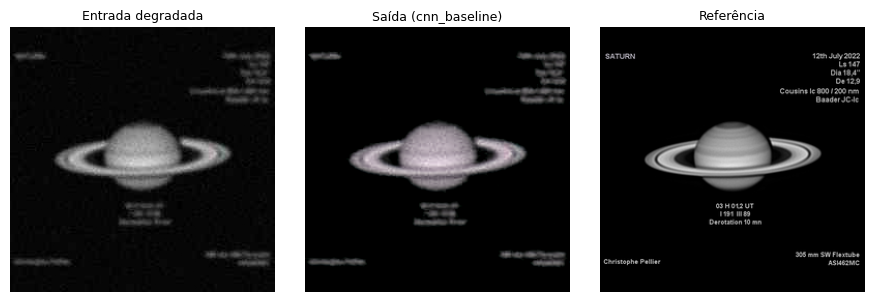

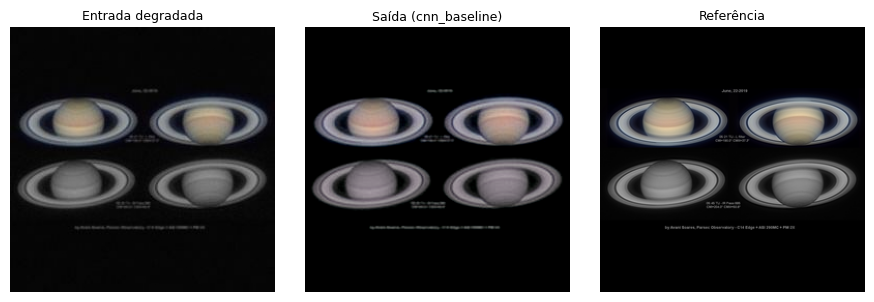

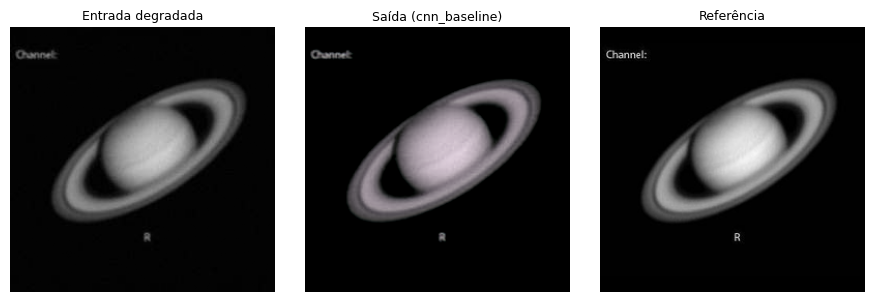

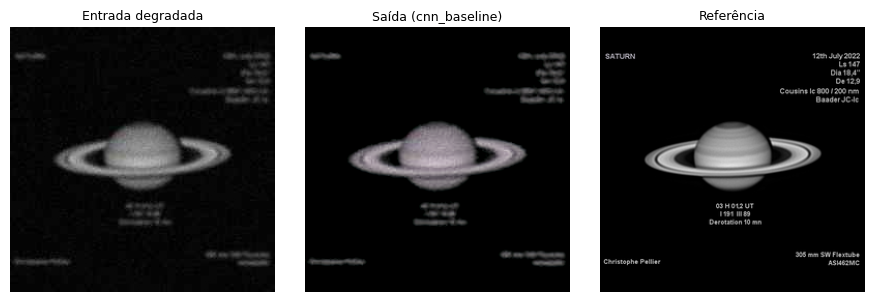

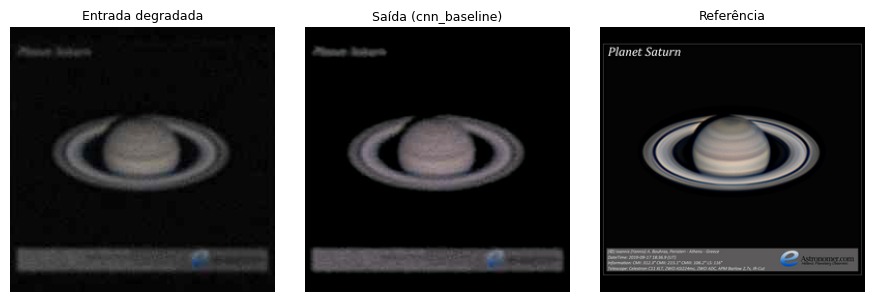

In [11]:
best_model.eval()
n_samples = 5
sample_indices = random.sample(range(len(test_dataset)), min(n_samples, len(test_dataset)))

with torch.no_grad():
    for idx in sample_indices:
        degraded, target = test_dataset[idx]
        output = best_model(degraded.unsqueeze(0).to(DEVICE)).cpu().squeeze(0)

        degraded_img = degraded.permute(1, 2, 0).numpy()
        output_img = output.permute(1, 2, 0).numpy()
        target_img = target.permute(1, 2, 0).numpy()

        plt.figure(figsize=(9, 3))
        for pos, (img, title) in enumerate([
            (degraded_img, "Entrada degradada"),
            (output_img, f"Saída ({best_model_name})"),
            (target_img, "Referência"),
        ]):
            plt.subplot(1, 3, pos + 1)
            plt.imshow(np.clip(img, 0, 1))
            plt.title(title, fontsize=9)
            plt.axis("off")
        plt.tight_layout()
        plt.show()

## 9.1 Mapas de explicabilidade

Esta célula gera três artefatos explicativos para algumas amostras de teste, usando
`best_model`: o mapa de diferença absoluta (|saída - entrada|), o mapa residual amplificado
(k × (saída - entrada), com k fixo), e o perfil radial de intensidade — uma média de brilho
por distância ao centro da imagem, que indica se a transição entre disco e anéis ficou mais
ou menos definida depois do processamento.

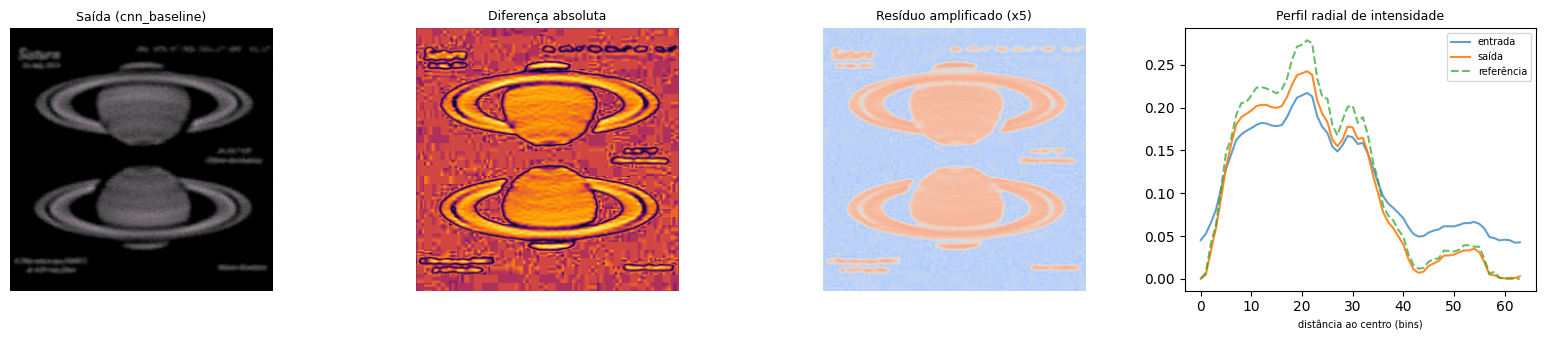

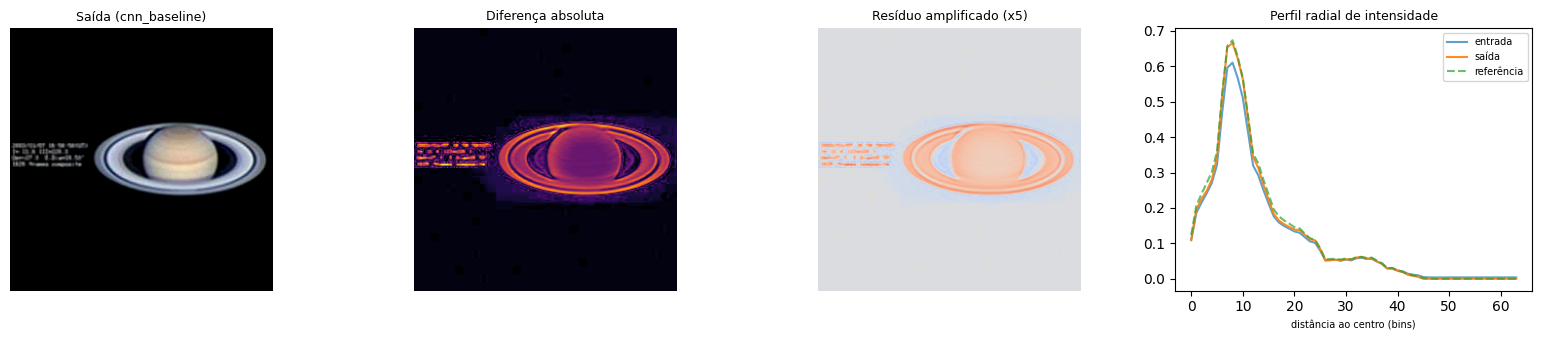

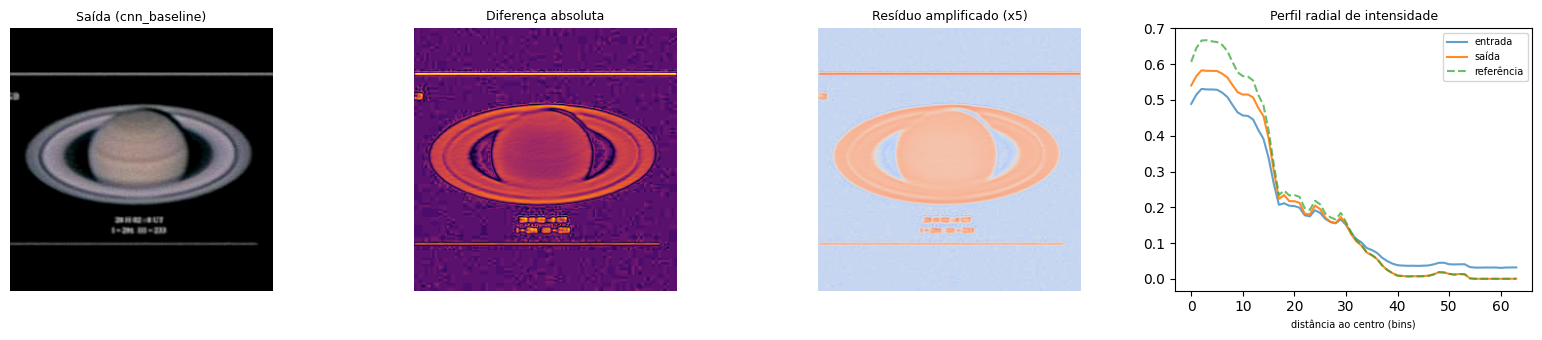

In [12]:
AMPLIFICATION_FACTOR = 5


def radial_intensity_profile(img_array, n_bins=64):
    h, w = img_array.shape[:2]
    gray = img_array.mean(axis=-1) if img_array.ndim == 3 else img_array
    cy, cx = h / 2.0, w / 2.0
    y_idx, x_idx = np.indices((h, w))
    radius = np.sqrt((y_idx - cy) ** 2 + (x_idx - cx) ** 2)
    max_radius = radius.max()
    bins = np.linspace(0, max_radius, n_bins + 1)
    profile = np.zeros(n_bins)
    for i in range(n_bins):
        mask = (radius >= bins[i]) & (radius < bins[i + 1])
        profile[i] = gray[mask].mean() if mask.any() else np.nan
    return profile


best_model.eval()
n_explain_samples = 3
explain_indices = random.sample(range(len(test_dataset)), min(n_explain_samples, len(test_dataset)))

with torch.no_grad():
    for idx in explain_indices:
        degraded, target = test_dataset[idx]
        output = best_model(degraded.unsqueeze(0).to(DEVICE)).cpu().squeeze(0)

        degraded_img = np.clip(degraded.permute(1, 2, 0).numpy(), 0, 1)
        output_img = np.clip(output.permute(1, 2, 0).numpy(), 0, 1)
        target_img = np.clip(target.permute(1, 2, 0).numpy(), 0, 1)

        diff_map = np.abs(output_img - degraded_img).mean(axis=-1)
        residual_map = np.clip(AMPLIFICATION_FACTOR * (output_img - degraded_img), -1, 1).mean(axis=-1)

        profile_input = radial_intensity_profile(degraded_img)
        profile_output = radial_intensity_profile(output_img)
        profile_target = radial_intensity_profile(target_img)

        fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
        axes[0].imshow(output_img)
        axes[0].set_title(f"Saída ({best_model_name})", fontsize=9)
        axes[0].axis("off")

        axes[1].imshow(diff_map, cmap="inferno")
        axes[1].set_title("Diferença absoluta", fontsize=9)
        axes[1].axis("off")

        axes[2].imshow(residual_map, cmap="coolwarm", vmin=-1, vmax=1)
        axes[2].set_title(f"Resíduo amplificado (x{AMPLIFICATION_FACTOR})", fontsize=9)
        axes[2].axis("off")

        axes[3].plot(profile_input, label="entrada", alpha=0.7)
        axes[3].plot(profile_output, label="saída", alpha=0.9)
        axes[3].plot(profile_target, label="referência", alpha=0.7, linestyle="--")
        axes[3].set_title("Perfil radial de intensidade", fontsize=9)
        axes[3].set_xlabel("distância ao centro (bins)", fontsize=7)
        axes[3].legend(fontsize=7)

        plt.tight_layout()
        plt.show()

## 10. Super-resolução para 1024px com modelo pré-treinado do Hugging Face

Esta é a etapa que leva as imagens de 256 para 1024 pixels, usando o Swin2SR
(`caidas/swin2SR-classical-sr-x4-64`), integrado à biblioteca `transformers`. Diferente das
quatro arquiteturas da seção 5, este modelo não é treinado neste notebook.

A função `enhance_and_upscale` encadeia dois modelos: primeiro a imagem normalizada de
256×256 passa por `best_model` (a arquitetura vencedora da seção 8), depois o resultado
passa pelo Swin2SR, que devolve uma reconstrução em 1024×1024. Essa ordem — modelo próprio
primeiro, super-resolução depois — evita que o Swin2SR amplifique o ruído junto com o resto
da imagem.

In [13]:
from transformers import AutoImageProcessor, Swin2SRForImageSuperResolution

sr_processor = AutoImageProcessor.from_pretrained(SR_MODEL_NAME)
sr_model = Swin2SRForImageSuperResolution.from_pretrained(SR_MODEL_NAME).to(DEVICE)
sr_model.eval()

print(f"Modelo de super-resolução carregado: {SR_MODEL_NAME}")
print(f"Modelo de realce usado antes da super-resolução: {best_model_name}")


def enhance_and_upscale(image_path, target_size=TARGET_UPSCALE_SIZE):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img_t = torch.from_numpy(np.asarray(img, dtype=np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        enhanced_t = best_model(img_t)
    enhanced_np = (enhanced_t.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255.0).round().astype(np.uint8)
    enhanced_img = Image.fromarray(enhanced_np)

    inputs = sr_processor(enhanced_img, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = sr_model(**inputs)

    reconstruction = outputs.reconstruction.data.squeeze().float().cpu().clamp_(0, 1).numpy()
    reconstruction = np.moveaxis(reconstruction, 0, -1)
    reconstruction = (reconstruction * 255.0).round().astype(np.uint8)
    upscaled_img = Image.fromarray(reconstruction)

    if upscaled_img.size != (target_size, target_size):
        upscaled_img = upscaled_img.resize((target_size, target_size), Image.Resampling.LANCZOS)

    return enhanced_img, upscaled_img

preprocessor_config.json:   0%|          | 0.00/152 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.1M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/726 [00:00<?, ?it/s]

Modelo de super-resolução carregado: caidas/swin2SR-classical-sr-x4-64
Modelo de realce usado antes da super-resolução: cnn_baseline


## 11. Rodando o pipeline completo sobre o catálogo mestre

Esta célula aplica `enhance_and_upscale` às imagens normalizadas da Fase 1, restrito às que
estão em `approved_image_ids` — a lista definida na seção 3.1, que agora reflete apenas a
decisão da própria Fase 1 (qualquer status diferente de `rejected`), sem nenhum filtro
adicional aplicado aqui. O resultado é salvo com um manifesto (`upscaled_manifest.csv`) que
registra o caminho de cada arquivo, a resolução final, o modelo de realce e o modelo de
super-resolução usados.

Para processar mais do que a amostra padrão, aumente `MAX_IMAGES_TO_UPSCALE` na seção 2 e
rode esta célula de novo — ela pula imagens que já têm uma versão em 1024 salva.

In [14]:
upscaled_manifest_path = DIRS["metadata"] / "upscaled_manifest.csv"
if upscaled_manifest_path.exists():
    upscaled_manifest_df = pd.read_csv(upscaled_manifest_path)
else:
    upscaled_manifest_df = pd.DataFrame(columns=[
        "image_id", "source_normalized_path", "upscaled_path",
        "width", "height", "enhance_model", "sr_model", "processed_at_utc",
    ])

already_upscaled = set(upscaled_manifest_df["image_id"].astype(str))

normalized_ok = normalized_manifest_df[normalized_manifest_df["status"] == "ok"].copy()
n_before_content_filter = len(normalized_ok)
normalized_ok = normalized_ok[normalized_ok["image_id"].astype(str).isin(approved_image_ids)]
n_removed_content = n_before_content_filter - len(normalized_ok)

to_process = normalized_ok[~normalized_ok["image_id"].astype(str).isin(already_upscaled)].reset_index(drop=True).head(MAX_IMAGES_TO_UPSCALE)

print(f"Imagens normalizadas disponíveis: {n_before_content_filter}")
print(f"Removidas por reprovação (status 'rejected' na Fase 1): {n_removed_content}")
print(f"{len(already_upscaled)} imagem(ns) já processada(s) em execuções anteriores.")
print(f"{len(to_process)} imagem(ns) será(ão) processada(s) nesta execução "
      f"(limite: {MAX_IMAGES_TO_UPSCALE}).\n")

new_records = []
for _, row in tqdm(to_process.iterrows(), total=len(to_process), desc=f"{best_model_name} + Swin2SR (256 -> 1024)"):
    image_id = row["image_id"]
    try:
        _, upscaled_img = enhance_and_upscale(row["normalized_path"])
        out_path = DIRS["upscaled_1024"] / f"{image_id}_1024.png"
        upscaled_img.save(out_path, "PNG", optimize=True)
        new_records.append({
            "image_id": image_id,
            "source_normalized_path": row["normalized_path"],
            "upscaled_path": str(out_path),
            "width": upscaled_img.width,
            "height": upscaled_img.height,
            "enhance_model": best_model_name,
            "sr_model": SR_MODEL_NAME,
            "processed_at_utc": utc_now_iso(),
        })
    except Exception as exc:
        print(f"Falha ao processar {image_id}: {type(exc).__name__}: {exc}")

if new_records:
    upscaled_manifest_df = pd.concat([upscaled_manifest_df, pd.DataFrame(new_records)], ignore_index=True)
    upscaled_manifest_df.to_csv(upscaled_manifest_path, index=False)

print(f"\nManifesto de imagens em alta resolução salvo em: {upscaled_manifest_path}")
print(f"Total de imagens em 1024x1024 até agora: {len(upscaled_manifest_df)}")

Imagens normalizadas disponíveis: 1000
Removidas por reprovação (status 'rejected' na Fase 1): 591
409 imagem(ns) já processada(s) em execuções anteriores.
0 imagem(ns) será(ão) processada(s) nesta execução (limite: 1000000).



cnn_baseline + Swin2SR (256 -> 1024): 0it [00:00, ?it/s]


Manifesto de imagens em alta resolução salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/upscaled_manifest.csv
Total de imagens em 1024x1024 até agora: 409


## 11.2 Reconciliação do catálogo em 1024px com a aprovação vigente

Esta célula é nova nesta versão. Como o critério de aprovação mudou (a Fase 2 deixou de
aplicar seu próprio filtro sobre o manifesto da Fase 1), imagens processadas em execuções
anteriores do `upscaled_manifest.csv` podem ter sido aprovadas sob critérios diferentes dos
vigentes agora — inclusive critérios mais restritivos, que hoje aprovariam mais imagens. Esta
célula não remove nada automaticamente; ela apenas confere e reporta qualquer divergência
entre o que já foi processado e o que a aprovação atual (`approved_image_ids`) considera
válido, para que a decisão de reprocessar ou manter fique explícita, e não escondida dentro
do comportamento "pula o que já existe" da célula anterior.

In [15]:
already_upscaled_ids = set(upscaled_manifest_df["image_id"].astype(str))
outside_current_approval = already_upscaled_ids - set(approved_image_ids)

print(f"Imagens em upscaled_manifest.csv: {len(already_upscaled_ids)}")
print(f"Imagens aprovadas pelo critério vigente: {len(approved_image_ids)}")
print(f"Imagens já processadas que NÃO estão na aprovação vigente: {len(outside_current_approval)}")

if len(outside_current_approval) > 0:
    print(
        "\nEssas imagens foram processadas sob um critério de aprovação anterior "
        "(possivelmente mais restritivo). Elas continuam no manifesto e nos arquivos em "
        "disco -- nenhuma foi apagada -- mas vale decidir explicitamente se devem ser "
        "mantidas no artigo/dataset final ou reprocessadas/reconferidas à luz do critério "
        "atual. Uma reconferência rápida é rodar novamente a validação de conteúdo "
        "(seção 3.1) da Fase 1 para essas image_id específicas, se ainda houver dúvida "
        "sobre o conteúdo delas."
    )
    reconciliation_path = DIRS["metadata"] / "upscaled_outside_current_approval.csv"
    pd.DataFrame({"image_id": sorted(outside_current_approval)}).to_csv(reconciliation_path, index=False)
    print(f"Lista salva em: {reconciliation_path}")
else:
    print("Nenhuma divergência: todas as imagens já processadas em 1024px seguem aprovadas pelo critério vigente.")

Imagens em upscaled_manifest.csv: 409
Imagens aprovadas pelo critério vigente: 409
Imagens já processadas que NÃO estão na aprovação vigente: 0
Nenhuma divergência: todas as imagens já processadas em 1024px seguem aprovadas pelo critério vigente.


## 11.3 Mapas de explicabilidade — catálogo final (1024px)

Esta célula estende a análise da seção 9.1 para todas as imagens já processadas em
`upscaled_manifest_df`, em vez de amostras aleatórias do split de teste sintético. Como são
fotos reais sem referência sintética, o mapa de diferença e o resíduo comparam a saída de
`best_model` contra a imagem normalizada original (ambas em 256px), e o perfil radial passa
a incluir também o resultado final em 1024px, após o Swin2SR. Os resultados quantitativos
por imagem vão para `explainability_summary.csv`, e as figuras individuais são salvas em
`explainability_1024/`.

In [16]:
best_model.eval()
explain_dir = DIRS["metadata"].parent / "explainability_1024"
explain_dir.mkdir(parents=True, exist_ok=True)

explain_records = []
with torch.no_grad():
    for _, row in tqdm(upscaled_manifest_df.iterrows(), total=len(upscaled_manifest_df), desc="Mapas de explicabilidade (catálogo final)"):
        image_id = row["image_id"]

        original_img = Image.open(row["source_normalized_path"]).convert("RGB")
        original_np = np.asarray(original_img, dtype=np.float32) / 255.0
        original_t = torch.from_numpy(original_np).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

        enhanced_t = best_model(original_t).cpu().squeeze(0)
        enhanced_img = np.clip(enhanced_t.permute(1, 2, 0).numpy(), 0, 1)

        final_img = np.asarray(Image.open(row["upscaled_path"]).convert("RGB"), dtype=np.float32) / 255.0

        diff_map = np.abs(enhanced_img - original_np).mean(axis=-1)
        residual_map = np.clip(AMPLIFICATION_FACTOR * (enhanced_img - original_np), -1, 1).mean(axis=-1)

        profile_input = radial_intensity_profile(original_np)
        profile_enhanced = radial_intensity_profile(enhanced_img)
        profile_final = radial_intensity_profile(final_img)

        explain_records.append({
            "image_id": image_id,
            "diff_mean": float(diff_map.mean()),
            "diff_max": float(diff_map.max()),
            "residual_mean_abs": float(np.abs(residual_map).mean()),
        })

        fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
        axes[0].imshow(enhanced_img)
        axes[0].set_title(f"Saída 256px ({best_model_name})", fontsize=9)
        axes[0].axis("off")

        axes[1].imshow(diff_map, cmap="inferno")
        axes[1].set_title("Diferença absoluta", fontsize=9)
        axes[1].axis("off")

        axes[2].imshow(residual_map, cmap="coolwarm", vmin=-1, vmax=1)
        axes[2].set_title(f"Resíduo amplificado (x{AMPLIFICATION_FACTOR})", fontsize=9)
        axes[2].axis("off")

        axes[3].plot(profile_input, label="entrada 256", alpha=0.7)
        axes[3].plot(profile_enhanced, label="saída 256", alpha=0.9)
        axes[3].plot(profile_final, label="final 1024", alpha=0.7, linestyle="--")
        axes[3].set_title("Perfil radial de intensidade", fontsize=9)
        axes[3].set_xlabel("distância ao centro (bins)", fontsize=7)
        axes[3].legend(fontsize=7)

        plt.tight_layout()
        fig.savefig(explain_dir / f"{image_id}_explain.png", dpi=110)
        plt.close(fig)

explain_summary_df = pd.DataFrame(explain_records)
explain_summary_path = DIRS["metadata"] / "explainability_summary.csv"
explain_summary_df.to_csv(explain_summary_path, index=False)

print(f"Mapas de explicabilidade gerados para {len(explain_summary_df)} imagem(ns) do catálogo final.")
print(f"Figuras individuais salvas em: {explain_dir}")
print(f"Resumo quantitativo salvo em: {explain_summary_path}")
print(explain_summary_df.describe()[["diff_mean", "diff_max", "residual_mean_abs"]].to_string())

Mapas de explicabilidade (catálogo final):   0%|          | 0/409 [00:00<?, ?it/s]

Mapas de explicabilidade gerados para 409 imagem(ns) do catálogo final.
Figuras individuais salvas em: /content/drive/MyDrive/dataset_saturno_v1/explainability_1024
Resumo quantitativo salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/explainability_summary.csv
        diff_mean    diff_max  residual_mean_abs
count  409.000000  409.000000         409.000000
mean     0.011518    0.160600           0.057129
std      0.006808    0.021355           0.033960
min      0.001556    0.094719           0.007472
25%      0.006523    0.146117           0.031959
50%      0.009425    0.160958           0.046806
75%      0.016081    0.175468           0.080027
max      0.039949    0.237908           0.199466


## 12. Conferência visual do resultado final em 1024px

Uma última checagem visual, ponta a ponta: a imagem normalizada original em 256×256 ao lado
da versão final em 1024×1024, já passada por `best_model` e pelo Swin2SR. Vale complementar
com PSNR/SSIM da seção 8.

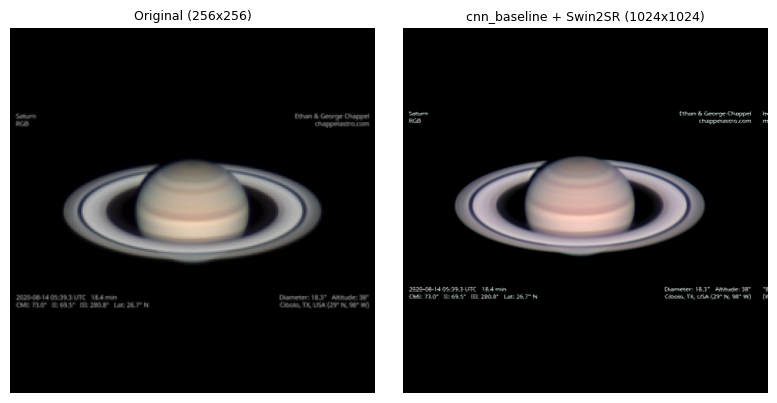

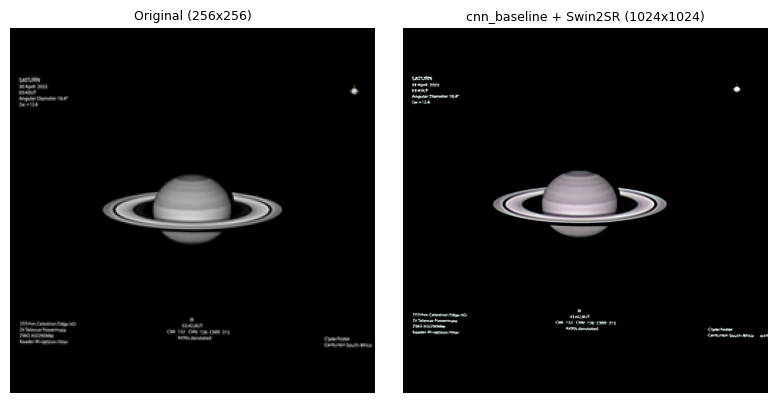

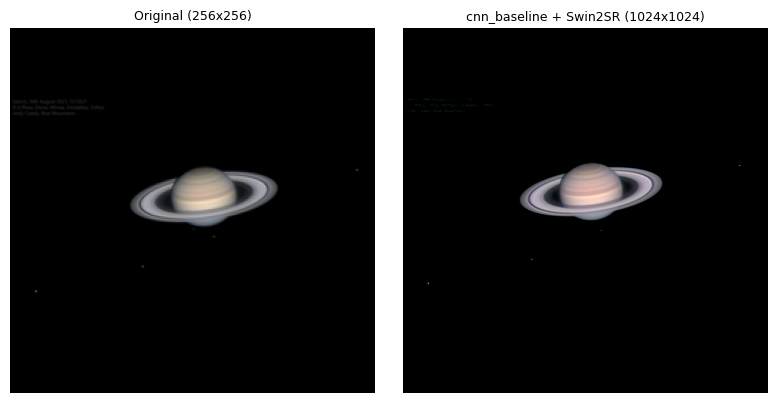

In [17]:
sample_rows = upscaled_manifest_df.sample(min(3, len(upscaled_manifest_df)), random_state=RANDOM_SEED)

for _, row in sample_rows.iterrows():
    original_img = Image.open(row["source_normalized_path"]).convert("RGB")
    final_img = Image.open(row["upscaled_path"]).convert("RGB")

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title(f"Original ({original_img.width}x{original_img.height})", fontsize=9)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(final_img)
    plt.title(f"{row.get('enhance_model', best_model_name)} + Swin2SR ({final_img.width}x{final_img.height})", fontsize=9)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## 13. Model card e resumo da Fase 2

Fechando o notebook, esta célula gera os artefatos de evidência que o relatório de auditoria
pede na camada de treinamento (seção 10): `training_run.json`, com o histórico e os
hiperparâmetros de todas as quatro arquiteturas, e `model_card.md`, no formato do Anexo A
do relatório. O texto do model card foi atualizado nesta versão para descrever a aprovação
de conteúdo em termos de "status excluído" (`PHASE1_REJECTED_STATUSES`) em vez de "status
aprovado", refletindo a correção desta versão: a Fase 2 documenta o que ela exclui, não uma
lista própria do que aceita.

In [18]:
if validation_source == "phase1_manifest_final_reviewed":
    content_validation_method = ("Manifesto final reaproveitado da Fase 1, com revisão manual "
                                  "aplicada (approved_for_training_final.csv)")
    total_classified = int(len(phase1_approval_df))
    status_col_used = "final_status" if "final_status" in phase1_approval_df.columns else "status"
    status_breakdown = phase1_approval_df[status_col_used].value_counts().to_dict()
elif validation_source == "phase1_manifest":
    content_validation_method = ("Manifesto reaproveitado da Fase 1, sem revisão manual "
                                  "aplicada (approved_for_training.csv)")
    total_classified = int(len(phase1_approval_df))
    status_breakdown = phase1_approval_df["status"].value_counts().to_dict()
else:
    content_validation_method = "Classificação própria da Fase 2 (CLIP zero-shot, fallback)"
    total_classified = int(len(strict_validation_df))
    status_breakdown = strict_validation_df["status"].value_counts().to_dict()

training_run = {
    "dataset_version": DATASET_NAME,
    "random_seed": RANDOM_SEED,
    "content_validation": {
        "method": content_validation_method,
        "validation_source": validation_source,
        "model": CLIP_MODEL_NAME,
        "confidence_threshold": STRICT_CONFIDENCE_THRESHOLD,
        "margin_threshold": STRICT_MARGIN_THRESHOLD,
        "borderline_confidence_threshold": STRICT_BORDERLINE_CONFIDENCE_THRESHOLD,
        "rejected_statuses": PHASE1_REJECTED_STATUSES,
        "approved_statuses_observed_this_run": approved_statuses_used,
        "images_in_master_catalog": int(len(master_df)),
        "images_classified": total_classified,
        "status_breakdown": {str(k): int(v) for k, v in status_breakdown.items()},
        "images_approved_for_training": int(len(approved_image_ids)),
        "quality_tier_breakdown": {str(k): int(v) for k, v in quality_tier_counts.items()},
        "synthetic_pairs_before_filter": int(n_pairs_before_filter),
        "synthetic_pairs_after_filter": int(len(pairs_df_filtered)),
    },
    "data_augmentation": {
        "enabled": AUGMENT_TRAIN_PAIRS,
        "horizontal_flip_probability": 0.5 if AUGMENT_TRAIN_PAIRS else None,
        "max_rotation_degrees": AUGMENT_MAX_ROTATION_DEGREES if AUGMENT_TRAIN_PAIRS else None,
        "applied_to_splits": ["train"],
    },
    "training_infrastructure": {
        "amp_enabled": USE_AMP,
        "device": str(DEVICE),
        "resumable_checkpoints": True,
    },
    "loss_function": {
        "description": "L1 + (1-SSIM) + gradiente (Sobel) + cor, pesos conforme seção 8.2 do relatório de auditoria",
        "weights": {
            "l1": LOSS_WEIGHT_L1,
            "ssim": LOSS_WEIGHT_SSIM,
            "gradient": LOSS_WEIGHT_GRADIENT,
            "color": LOSS_WEIGHT_COLOR,
        },
    },
    "shared_hyperparameters": {
        "batch_size": BATCH_SIZE,
        "epochs_configured": NUM_EPOCHS,
        "learning_rate_initial": LEARNING_RATE,
        "lr_scheduler": {"type": "ReduceLROnPlateau", "factor": LR_SCHEDULER_FACTOR, "patience": LR_SCHEDULER_PATIENCE},
        "grad_clip_max_norm": GRAD_CLIP_MAX_NORM,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    },
    "models": {
        name: {
            "parameters": int(count_params(trained_models[name])),
            "epochs_run": len(training_histories[name]["epoch"]),
            "best_epoch": int(best_checkpoints[name]["epoch"]),
            "best_val_loss": float(best_checkpoints[name]["val_loss"]),
            "learning_rate_final": training_histories[name]["learning_rate"][-1],
            "history": training_histories[name],
        }
        for name in trained_models
    },
    "model_comparison_test_set": comparison_df.to_dict(orient="records"),
    "best_model_by_ssim": best_model_name,
    "best_model_by_lpips": best_by_lpips,
    "evaluation_by_severity": severity_summary.to_dict(orient="records"),
    "upscaled_catalog_reconciliation": {
        "images_in_upscaled_manifest": int(len(upscaled_manifest_df)),
        "images_outside_current_approval": int(len(outside_current_approval)),
    },
    "super_resolution": {
        "model_name": SR_MODEL_NAME,
        "source": "Hugging Face (modelo pré-treinado, não treinado neste notebook)",
        "scale_factor": 4,
        "input_size": IMAGE_SIZE,
        "output_size": TARGET_UPSCALE_SIZE,
        "images_processed": int(len(upscaled_manifest_df)),
    },
    "generated_at_utc": utc_now_iso(),
}

training_run_path = DIRS["metadata"] / "training_run.json"
training_run_path.write_text(json.dumps(training_run, indent=2, ensure_ascii=False), encoding="utf-8")

comparison_table_md = comparison_df.to_string(index=False)
severity_table_md = severity_summary.to_string(index=False)

lpips_agreement_note = (
    f"O melhor modelo por SSIM ({best_model_name}) também é o melhor por LPIPS."
    if best_by_lpips == best_model_name else
    f"Atenção: o melhor modelo por SSIM ({best_model_name}) difere do melhor por LPIPS ({best_by_lpips})."
)

reconciliation_note = (
    "Todas as imagens já processadas em 1024px seguem aprovadas pelo critério vigente."
    if len(outside_current_approval) == 0 else
    f"{len(outside_current_approval)} imagem(ns) já processada(s) em 1024px foram aprovadas "
    "sob um critério de aprovação anterior e não constam na aprovação vigente calculada "
    "nesta execução -- ver upscaled_outside_current_approval.csv (seção 11.2) antes de "
    "usar essas imagens como evidência final."
)

model_card = f'''# Model Card — Fase 2, comparação de arquiteturas (Projeto IA Saturno)

## Finalidade
Redução de ruído e realce de imagens amadoras de Saturno em 256x256, como etapa de
pré-processamento antes da super-resolução para 1024x1024. Parte da Fase 2 do desenho
experimental descrito no relatório de auditoria técnica do projeto.

## Aprovação de conteúdo
{content_validation_method}. A Fase 2 não define uma lista própria de status aprovados:
qualquer status diferente de {PHASE1_REJECTED_STATUSES} é tratado como aprovado para
treino, e essa decisão pertence inteiramente à Fase 1. Nesta execução, os status observados
como aprovados foram {approved_statuses_used}. De {len(master_df)} imagens no catálogo,
{len(approved_image_ids)} foram aprovadas; os pares sintéticos usados no treinamento foram
de {n_pairs_before_filter} para {len(pairs_df_filtered)} após esse filtro. Distribuição de
status no manifesto de origem: {status_breakdown}.

Dentro das aprovadas, a distribuição por camada de qualidade é {quality_tier_counts}, onde
"high" corresponde a confirmação automática de alta confiança ou revisão manual explícita, e
"low" corresponde a imagens aprovadas por decisão do projeto a partir da fila borderline, sem
revisão manual concluída (status confirmed_pending_review na Fase 1). Essa camada "low" deve
ser reportada explicitamente no artigo como uma escolha deliberada de priorizar volume de
dados sobre um filtro de conteúdo mais rígido, e não como uma confirmação de conteúdo
equivalente à camada "high".

## Reconciliação com o catálogo já processado em 1024px
{reconciliation_note}

## Dados
Treinado sobre os pares sintéticos degradado/referência gerados na Fase 1, já filtrados
pela aprovação de conteúdo acima, com aumento de dados (espelhamento horizontal + rotação
de até {AUGMENT_MAX_ROTATION_DEGREES} graus) aplicado apenas ao split de treino. Split:
{len(train_dataset)} pares de treino, {len(val_dataset)} de validação, {len(test_dataset)}
de teste.

## Arquiteturas comparadas
CNN baseline (3 camadas, aprendizado residual), autoencoder convolucional, DnCNN (15
camadas, aprendizado de resíduo de ruído) e U-Net pequena (encoder-decoder com conexões de
atalho). Todas treinadas com a mesma função de perda, os mesmos hiperparâmetros e o mesmo
critério de parada antecipada.

## Comparação no split de teste
{comparison_table_md}

Arquitetura escolhida para a etapa de super-resolução: {best_model_name} (melhor SSIM
médio). {lpips_agreement_note}

## Desempenho por severidade de degradação ({best_model_name})
{severity_table_md}

## Super-resolução (não treinada neste notebook)
A etapa de aumento de resolução para 1024x1024 usa o modelo pré-treinado {SR_MODEL_NAME},
publicado no Hugging Face, aplicado após a saída de {best_model_name}.

## Limites
Métricas calculadas contra referência sintética, não contra observação astronômica
independente. O desempenho varia por severidade de degradação, como mostrado acima. O
número de pares efetivamente usados no treino depende diretamente do estado da revisão
manual da fila borderline na Fase 1 -- um dataset pequeno favorece modelos com menos
parâmetros independentemente do mérito da arquitetura, e isso deve ser reportado
explicitamente ao comparar arquiteturas de capacidades diferentes. Parte do conjunto aprovado
nesta execução ({quality_tier_counts}) vem da camada "low" (fila borderline aceita sem
revisão manual concluída, por decisão do projeto); qualquer leitura da comparação entre
arquiteturas deveria, idealmente, ser refeita restringindo a avaliação apenas à camada "high"
para confirmar que a conclusão se sustenta sem o conteúdo de aceitação mais permissiva. Qualquer
imagem em 1024x1024 gerada por este pipeline deve ser tratada como imagem processada por IA,
não como observação bruta.

## Riscos
Uso da saída como se fosse observação astronômica bruta; publicação sem marcação de
"imagem processada por IA"; generalização não verificada para condições de captura muito
diferentes das representadas nos pares de treino; comparação entre arquiteturas de
capacidades muito diferentes treinadas sobre um dataset efetivo pequeno; imagens já
processadas em 1024px sob um critério de aprovação anterior sendo usadas sem reconciliação
com o critério vigente; agregação da métrica principal misturando conteúdo confirmado
(quality_tier='high') com conteúdo ainda pendente de revisão manual (quality_tier='low'),
sem reportar as duas camadas separadamente.

## Uso permitido
Uso interno de pesquisa e como base para discussão metodológica na dissertação. Publicação
de imagens geradas exige a mesma marcação de proveniência definida na Fase 1.
'''

model_card_path = DIRS["metadata"] / "model_card.md"
model_card_path.write_text(model_card, encoding="utf-8")

print(f"training_run.json salvo em: {training_run_path}")
print(f"model_card.md salvo em: {model_card_path}")

training_run.json salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/training_run.json
model_card.md salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/model_card.md
